# ThinkLab NLP Project

## Product Review Sentiment Classification

**Member:** Buddhisha  
**Machine Learning Model:** Logistic Regression  
**Deep Learning Model:** LSTM

### Import Required Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

### Upload the Dataset

In [15]:
uploaded = files.upload()

Saving Womens Clothing E-Commerce Reviews.csv to Womens Clothing E-Commerce Reviews.csv


### Load and Preview the Dataset

In [16]:
filename = next(iter(uploaded))

dataset = pd.read_csv(filename)

print("Dataset loaded successfully")
print("Dataset shape:", dataset.shape)

dataset.head()

Dataset loaded successfully
Dataset shape: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


### Inspect Dataset Information

In [17]:
print("Dataset information:")
dataset.info()

print("\nMissing values in each column:")
print(dataset.isnull().sum())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB

Missing values in each column:
Unnamed: 0                    0
Clothing ID                   0
Age                           0
Tit

### Select and Clean Required Columns

In [18]:
# Select required columns
data = dataset[['Review Text', 'Rating']].copy()

print("Original records:", data.shape[0])

# Remove missing values
data = data.dropna(subset=['Review Text', 'Rating'])
print("After removing missing values:", data.shape[0])

# Remove duplicates
data = data.drop_duplicates()
print("After removing duplicates:", data.shape[0])

print("\nMissing values after cleaning:")
print(data.isnull().sum())

data.head()

Original records: 23486
After removing missing values: 22641
After removing duplicates: 22634

Missing values after cleaning:
Review Text    0
Rating         0
dtype: int64


,Review Text,Rating
0,Absolutely wonderful - silky and sexy and comf...,4
1,Love this dress! it's sooo pretty. i happene...,5
2,I had such high hopes for this dress and reall...,3
3,"I love, love, love this jumpsuit. it's fun, fl...",5
4,This shirt is very flattering to all due to th...,5


### Create Sentiment Labels


In [19]:
# Create sentiment labels
def create_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

data['Sentiment'] = data['Rating'].apply(create_sentiment)

data[['Review Text', 'Rating', 'Sentiment']].head(10)

,Review Text,Rating,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,Positive
1,Love this dress! it's sooo pretty. i happene...,5,Positive
2,I had such high hopes for this dress and reall...,3,Neutral
3,"I love, love, love this jumpsuit. it's fun, fl...",5,Positive
4,This shirt is very flattering to all due to th...,5,Positive
5,"I love tracy reese dresses, but this one is no...",2,Negative
6,I aded this in my basket at hte last mintue to...,5,Positive
7,"I ordered this in carbon for store pick up, an...",4,Positive
8,I love this dress. i usually get an xs but it ...,5,Positive
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",5,Positive


### Verify Rating and Sentiment Mapping


In [20]:
# Check the rating and sentiment mapping
print(
    data[['Rating', 'Sentiment']]
    .drop_duplicates()
    .sort_values('Rating')
)

    Rating Sentiment
61       1  Negative
5        2  Negative
2        3   Neutral
0        4  Positive
1        5  Positive


### Count Sentiment Classes


In [21]:
# Count reviews in each sentiment class
sentiment_counts = data['Sentiment'].value_counts()

print("Each sentiment class counts:")
print(sentiment_counts)

Each sentiment class counts:
Sentiment
Positive    17442
Neutral      2823
Negative     2369
Name: count, dtype: int64


### Visualize Sentiment Distribution

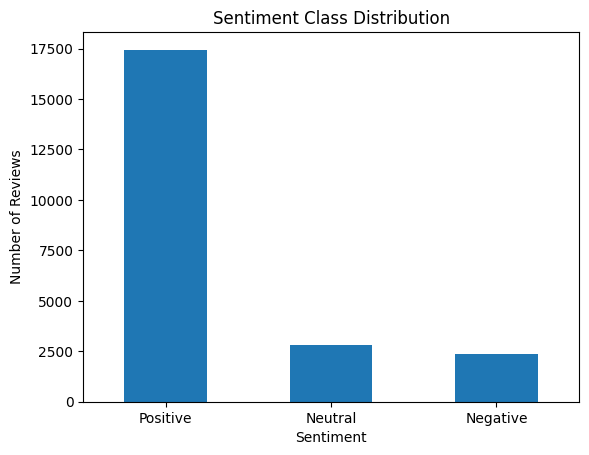

In [22]:
# Display sentiment class distribution
sentiment_counts.plot(kind='bar')

plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

### Analyze Review Lengths

In [23]:
# Calculate the number of words in each review
data['Review Length'] = data['Review Text'].str.split().str.len()

print("Review length summary:")
print(data['Review Length'].describe())

Review length summary:
count    22634.000000
mean        60.199214
std         28.533191
min          2.000000
25%         36.000000
50%         59.000000
75%         88.000000
max        115.000000
Name: Review Length, dtype: float64


### Visualize Review Length Distribution

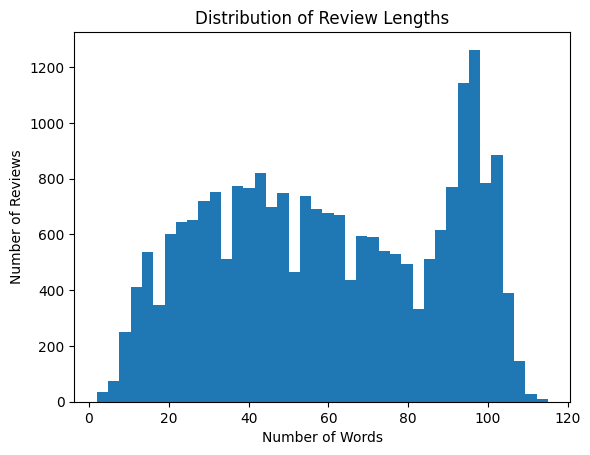

In [24]:
# Review length distribution
data['Review Length'].plot(kind='hist', bins=40)

plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')
plt.show()

### Preview the Updated Dataset

In [ ]:
data.head()

,Review Text,Rating,Sentiment,Review Length
0,Absolutely wonderful - silky and sexy and comf...,4,Positive,8
1,Love this dress! it's sooo pretty. i happene...,5,Positive,62
2,I had such high hopes for this dress and reall...,3,Neutral,98
3,"I love, love, love this jumpsuit. it's fun, fl...",5,Positive,22
4,This shirt is very flattering to all due to th...,5,Positive,36


### Perform Basic Text Cleaning

In [25]:
import re

# Clean review text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['Cleaned Review'] = data['Review Text'].apply(clean_text)

data[['Review Text', 'Cleaned Review']].head(10)

,Review Text,Cleaned Review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,love this dress it s sooo pretty i happened to...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit it s fun flirty...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...
5,"I love tracy reese dresses, but this one is no...",i love tracy reese dresses but this one is not...
6,I aded this in my basket at hte last mintue to...,i aded this in my basket at hte last mintue to...
7,"I ordered this in carbon for store pick up, an...",i ordered this in carbon for store pick up and...
8,I love this dress. i usually get an xs but it ...,i love this dress i usually get an xs but it r...
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",i m and lbs i ordered the s petite to make sur...


### Check Empty Cleaned Reviews

In [26]:
# Check for empty reviews after cleaning
empty_reviews = (data['Cleaned Review'].str.len() == 0).sum()

print("Empty reviews after cleaning:", empty_reviews)

Empty reviews after cleaning: 0


### Download NLTK Resources

In [27]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### Apply Advanced Text Preprocessing

In [28]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Prepare stop words and lemmatizer
stop_words = set(stopwords.words('english'))

# Keep important negative words for sentiment analysis
stop_words.discard('not')
stop_words.discard('no')
stop_words.discard('nor')

lemmatizer = WordNetLemmatizer()


def process_text(text):
    # Tokenization
    words = text.split()

    # Remove stop words and apply lemmatization
    processed_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(processed_words)


data['Processed Review'] = data['Cleaned Review'].apply(process_text)

data[['Review Text', 'Cleaned Review', 'Processed Review']].head(10)

,Review Text,Cleaned Review,Processed Review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,love this dress it s sooo pretty i happened to...,love dress sooo pretty happened find store gla...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...,high hope dress really wanted work initially o...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit it s fun flirty...,love love love jumpsuit fun flirty fabulous ev...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...
5,"I love tracy reese dresses, but this one is no...",i love tracy reese dresses but this one is not...,love tracy reese dress one not petite foot tal...
6,I aded this in my basket at hte last mintue to...,i aded this in my basket at hte last mintue to...,aded basket hte last mintue see would look lik...
7,"I ordered this in carbon for store pick up, an...",i ordered this in carbon for store pick up and...,ordered carbon store pick ton stuff always try...
8,I love this dress. i usually get an xs but it ...,i love this dress i usually get an xs but it r...,love dress usually get x run little snug bust ...
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",i m and lbs i ordered the s petite to make sur...,lb ordered petite make sure length long typica...


### Check Empty Processed Reviews

In [ ]:
# Check for empty processed reviews
empty_processed_reviews = (
    data['Processed Review'].str.strip() == ''
).sum()

print("Empty processed reviews:", empty_processed_reviews)

Empty processed reviews: 0


### Split the Dataset

In [ ]:
from sklearn.model_selection import train_test_split

# Select input text and target sentiment
X = data['Processed Review']
y = data['Sentiment']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", X_train.shape[0])
print("Testing reviews:", X_test.shape[0])

Training reviews: 18107
Testing reviews: 4527


##  Logistic Regression Model

### TF-IDF Feature Extraction

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert training text into numerical features
tfidf = TfidfVectorizer(max_features=10000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

Training feature shape: (18107, 10000)
Testing feature shape: (4527, 10000)


### Train the Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Train the model
logistic_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!!")

Logistic Regression model trained successfully!!


### Generate Logistic Regression Predictions

In [ ]:
# Predict sentiment for testing reviews
y_pred = logistic_model.predict(X_test_tfidf)

print("Predictions completed")
print("First 10 predictions:")
print(y_pred[:10])

Predictions completed
First 10 predictions:
['Positive' 'Positive' 'Positive' 'Negative' 'Neutral' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive']


### Evaluate Logistic Regression Performance

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Calculate evaluation scores
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='macro',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average='macro',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average='macro',
    zero_division=0
)

print("Logistic Regression Results")
print("Accuracy:", round(accuracy, 4))
print("Macro Precision:", round(precision, 4))
print("Macro Recall:", round(recall, 4))
print("Macro F1-Score:", round(f1, 4))

Logistic Regression Results
Accuracy: 0.7674
Macro Precision: 0.5787
Macro Recall: 0.6434
Macro F1-Score: 0.601


### Logistic Regression Classification Report

In [ ]:
labels = ['Negative', 'Neutral', 'Positive']

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        labels=labels,
        digits=4,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

    Negative     0.4584    0.6160    0.5257       474
     Neutral     0.3253    0.4796    0.3877       565
    Positive     0.9522    0.8346    0.8895      3488

    accuracy                         0.7674      4527
   macro avg     0.5787    0.6434    0.6010      4527
weighted avg     0.8223    0.7674    0.7888      4527



### Logistic Regression Confusion Matrix

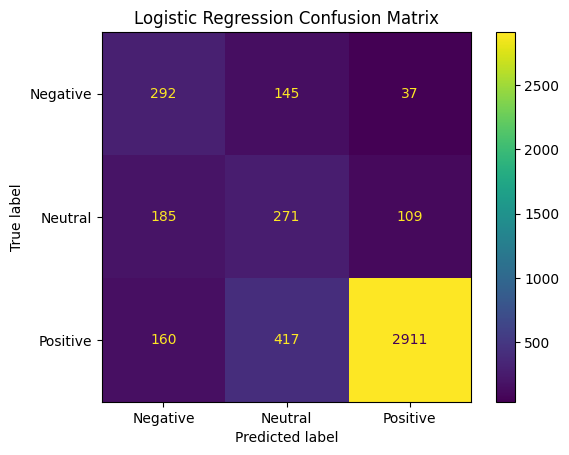

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=labels
)

plt.title('Logistic Regression Confusion Matrix')
plt.show()

## LSTM Model

### Prepare LSTM Data

In [ ]:
# Prepare text data for LSTM
from sklearn.preprocessing import LabelEncoder

X_train_lstm = data.loc[X_train.index, 'Cleaned Review']
X_test_lstm = data.loc[X_test.index, 'Cleaned Review']

# Encode sentiment labels
label_encoder = LabelEncoder()

y_train_lstm = label_encoder.fit_transform(y_train)
y_test_lstm = label_encoder.transform(y_test)

print(label_encoder.classes_)
print(y_train_lstm[:10])

['Negative' 'Neutral' 'Positive']
[2 2 2 2 2 2 1 1 2 1]


### Tokenize and Pad Review Text


In [ ]:
# Import tokenizer and padding tools
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences

# Set tokenizer parameters
vocab_size = 10000
max_length = 100

# Create the tokenizer
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

# Learn the vocabulary only from the training reviews
tokenizer.fit_on_texts(X_train_lstm)

# Convert reviews into number sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train_lstm)
X_test_sequences = tokenizer.texts_to_sequences(X_test_lstm)

# Make every sequence the same length
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

# Display the results
print("Training shape:", X_train_padded.shape)
print("Testing shape:", X_test_padded.shape)
print("First padded sequence:")
print(X_train_padded[0])

Training shape: (18107, 100)
Testing shape: (4527, 100)
First padded sequence:
[   3   27    8   10    2  159 1068   49    5    3   23    4   17  559
    3   35  899  563    4   10  107   94    8  305    7  434   69    5
   64  103  207  210  420    6  380  536    4   30  132    9   25   12
   33   99  419    4   22    6   76  593 1632   17   52   41  214    6
  726   30  987  288   45    2  121  365  108    2  159    7   20    4
   22   21  258   34  388   34   10    2  283   12    2  887    3  228
  102   44  191   58 3603   14  618 1027   53  602    0    0    0    0
    0    0]


### Build the LSTM Model

In [ ]:
# Build the LSTM model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense

lstm_model = Sequential([
    tf.keras.Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=64),
    LSTM(64),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

# Compile the model
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,219 (2.57 MB)

 Trainable params: 673,219 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Initial LSTM Model

In [ ]:
# Train the LSTM model
history = lstm_model.fit(
    X_train_padded,
    y_train_lstm,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 35s 66ms/step - accuracy: 0.7659 - loss: 0.7210 - val_accuracy: 0.7797 - val_loss: 0.6765
Epoch 2/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.7693 - loss: 0.6955 - val_accuracy: 0.7844 - val_loss: 0.6585
Epoch 3/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.7722 - loss: 0.6775 - val_accuracy: 0.7789 - val_loss: 0.6202
Epoch 4/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.7644 - loss: 0.6972 - val_accuracy: 0.7789 - val_loss: 0.6778
Epoch 5/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.7721 - loss: 0.6361 - val_accuracy: 0.7805 - val_loss: 0.4809


### Evaluate the Initial LSTM Model


In [ ]:
# Predict sentiments using the LSTM model
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, classification_report

y_lstm_probabilities = lstm_model.predict(X_test_padded)
y_lstm_pred = np.argmax(y_lstm_probabilities, axis=1)

# Evaluate the LSTM model
lstm_accuracy = accuracy_score(y_test_lstm, y_lstm_pred)
lstm_precision = precision_score(
    y_test_lstm, y_lstm_pred, average="macro", zero_division=0
)
lstm_recall = recall_score(
    y_test_lstm, y_lstm_pred, average="macro", zero_division=0
)
lstm_f1 = f1_score(
    y_test_lstm, y_lstm_pred, average="macro", zero_division=0
)

print("Accuracy:", round(lstm_accuracy, 4))
print("Macro Precision:", round(lstm_precision, 4))
print("Macro Recall:", round(lstm_recall, 4))
print("Macro F1-score:", round(lstm_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test_lstm,
    y_lstm_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
Accuracy: 0.77
Macro Precision: 0.3657
Macro Recall: 0.342
Macro F1-score: 0.3098

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       474
     Neutral       0.32      0.03      0.06       565
    Positive       0.78      0.99      0.87      3488

    accuracy                           0.77      4527
   macro avg       0.37      0.34      0.31      4527
weighted avg       0.64      0.77      0.68      4527



### Class Weight Calculation

### Class Weight Calculation

In [ ]:
# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_lstm)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_lstm
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(3.1850483729111696), np.int64(1): np.float64(2.673014467080012), np.int64(2): np.float64(0.4325402513018967)}


### LSTM Retraining with Class Weights

In [ ]:
# Rebuild the LSTM model
weighted_lstm_model = Sequential([
    tf.keras.Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=64),
    LSTM(64),
    Dropout(0.5),
    Dense(3, activation="softmax")
])

weighted_lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Retrain using class weights
weighted_history = weighted_lstm_model.fit(
    X_train_padded,
    y_train_lstm,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 42s 82ms/step - accuracy: 0.2596 - loss: 1.1064 - val_accuracy: 0.7551 - val_loss: 1.0393
Epoch 2/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.3279 - loss: 1.1010 - val_accuracy: 0.7598 - val_loss: 1.0172
Epoch 3/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 46s 77ms/step - accuracy: 0.3577 - loss: 1.0892 - val_accuracy: 0.1615 - val_loss: 1.1730
Epoch 4/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.5970 - loss: 0.9957 - val_accuracy: 0.7579 - val_loss: 0.7107
Epoch 5/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.6908 - loss: 1.0035 - val_accuracy: 0.7112 - val_loss: 0.9653


### Weighted LSTM Model Evaluation

In [ ]:
# Predict sentiments using the weighted LSTM model
y_weighted_probabilities = weighted_lstm_model.predict(X_test_padded)
y_weighted_pred = np.argmax(y_weighted_probabilities, axis=1)

# Evaluate the weighted LSTM model
weighted_accuracy = accuracy_score(y_test_lstm, y_weighted_pred)
weighted_precision = precision_score(
    y_test_lstm, y_weighted_pred, average="macro", zero_division=0
)
weighted_recall = recall_score(
    y_test_lstm, y_weighted_pred, average="macro", zero_division=0
)
weighted_f1 = f1_score(
    y_test_lstm, y_weighted_pred, average="macro", zero_division=0
)

print("Accuracy:", round(weighted_accuracy, 4))
print("Macro Precision:", round(weighted_precision, 4))
print("Macro Recall:", round(weighted_recall, 4))
print("Macro F1-score:", round(weighted_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test_lstm,
    y_weighted_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step
Accuracy: 0.7022
Macro Precision: 0.4383
Macro Recall: 0.4951
Macro F1-score: 0.4408

Classification Report:
              precision    recall  f1-score   support

    Negative       0.28      0.60      0.38       474
     Neutral       0.16      0.07      0.10       565
    Positive       0.87      0.82      0.85      3488

    accuracy                           0.70      4527
   macro avg       0.44      0.50      0.44      4527
weighted avg       0.72      0.70      0.70      4527



### Weighted LSTM Confusion Matrix

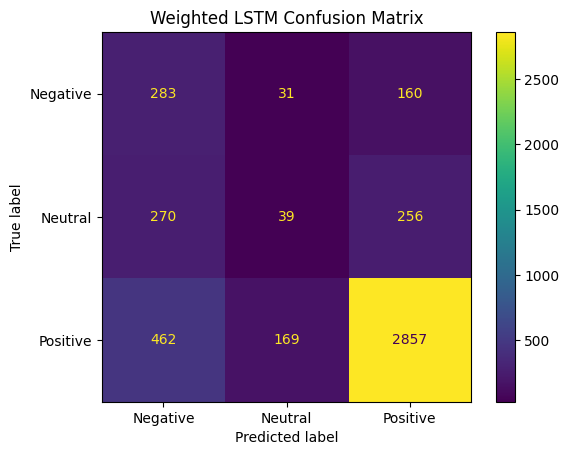

In [ ]:
# Display the weighted LSTM confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

weighted_cm = confusion_matrix(y_test_lstm, y_weighted_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=weighted_cm,
    display_labels=label_encoder.classes_
)

display.plot(cmap="viridis")
plt.title("Weighted LSTM Confusion Matrix")
plt.show()

### Save the Logistic Regression Model

In [ ]:
# Save the Logistic Regression model and TF-IDF vectorizer
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    logistic_model,
    "models/logistic_regression_model.pkl"
)

joblib.dump(
    tfidf,
    "models/tfidf_vectorizer.pkl"
)

print("Logistic Regression model and TF-IDF vectorizer saved successfully.")

Logistic Regression model and TF-IDF vectorizer saved successfully.


### Save the Weighted LSTM Model

In [ ]:
# Save the weighted LSTM model and preprocessing objects
import pickle

weighted_lstm_model.save("models/weighted_lstm_model.keras")

with open("models/lstm_tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

with open("models/label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

print("Weighted LSTM model and preprocessing objects saved successfully.")

Weighted LSTM model and preprocessing objects saved successfully.


### Create the Models ZIP File

In [ ]:
# Create a ZIP file containing all saved models
import shutil

shutil.make_archive("models", "zip", "models")

print("Models ZIP file created successfully.")

Models ZIP file created successfully.


## Model Performance Comparison

This section compares the performance of the Logistic Regression and Weighted LSTM models using accuracy, macro precision, macro recall, and macro F1-score.

In [ ]:
# Create a model performance comparison table using saved results
comparison_data = {
    "Model": [
        "Logistic Regression",
        "Weighted LSTM"
    ],
    "Accuracy": [
        0.7674,
        0.7022
    ],
    "Macro Precision": [
        0.5787,
        0.4383
    ],
    "Macro Recall": [
        0.6434,
        0.4951
    ],
    "Macro F1-Score": [
        0.6010,
        0.4408
    ]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,Logistic Regression,0.7674,0.5787,0.6434,0.6010
1,Weighted LSTM,0.7022,0.4383,0.4951,0.4408


### Model Performance Comparison Chart

This chart visually compares the evaluation scores of the Logistic Regression and Weighted LSTM models.

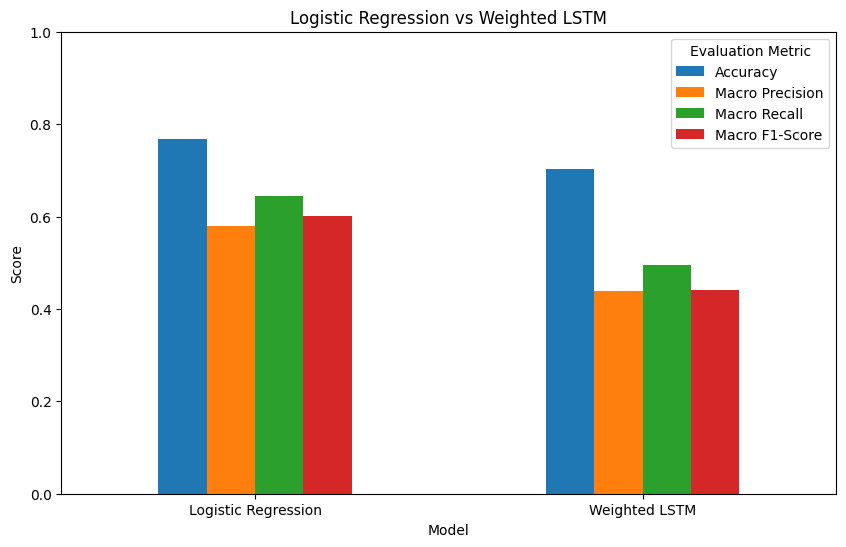

In [ ]:
# Plot model performance comparison
comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Logistic Regression vs Weighted LSTM")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metric")
plt.show()

### Comparison Result

Logistic Regression model is the best overall performance model. Accuracy is 0.7674 and macro F1-score is 0.6010. The Weighted LSTM model got an accuracy of 0.7022 and a macro F1-score of 0.4408. Therefore, Logistic Regression was selected as the best performing model between these two models.

In [ ]:
# Download the saved model files from GitHub
import os

os.makedirs("models", exist_ok=True)

!wget -q -O models/logistic_regression_model.pkl https://raw.githubusercontent.com/Cpox123/ThinkLab-NLP/buddhisha/models/logistic_regression_model.pkl
!wget -q -O models/tfidf_vectorizer.pkl https://raw.githubusercontent.com/Cpox123/ThinkLab-NLP/buddhisha/models/tfidf_vectorizer.pkl

print("Model files downloaded successfully.")

Model files downloaded successfully.


## Custom Review Sentiment Prediction

This section uses the saved Logistic Regression model to predict the sentiment of a new product review.

In [ ]:
# Load the saved model and vectorizer
import joblib

loaded_model = joblib.load(
    "models/logistic_regression_model.pkl"
)

loaded_tfidf = joblib.load(
    "models/tfidf_vectorizer.pkl"
)

# Enter a custom product review
custom_review = "The dress is beautiful, comfortable, and fits perfectly."

# Preprocess the review
cleaned_review = clean_text(custom_review)
processed_review = process_text(cleaned_review)

# Predict the sentiment
review_tfidf = loaded_tfidf.transform([processed_review])
prediction = loaded_model.predict(review_tfidf)[0]

print("Review:", custom_review)
print("Predicted Sentiment:", prediction)

Review: The dress is beautiful, comfortable, and fits perfectly.
Predicted Sentiment: Positive


### Prediction Result

The saved Logistic Regression model successfully predicted the custom product review as Positive. This confirms that the trained model and TF-IDF vectorizer can be loaded and used for new review sentiment prediction.